In [7]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [10]:
#グリッドリサーチは基本的にはパラメータの組み合わせを総当たりで試す方法である

#単純なグリッドサーチ
from sklearn.svm import SVC
from sklearn.datasets import load_iris

iris = load_iris()

x_train,x_test,y_train,y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=0
)

print("Size of training set:{}".format(x_train.shape[0]))
print("Size of test set:{}".format(x_test.shape[0]))

best_score = 0

for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        svm = SVC(gamma=gamma,C=C)
        svm.fit(x_train,y_train)
        score = svm.score(x_test,y_test)
        if score > best_score:
            best_score = score
            best_parameters = {'C':C,'gamma':gamma}

print("Best score:{:.2f}".format(best_score))
print("Best parameters:{}".format(best_parameters))

Size of training set:112
Size of test set:38
Best score:0.97
Best parameters:{'C': 100, 'gamma': 0.001}


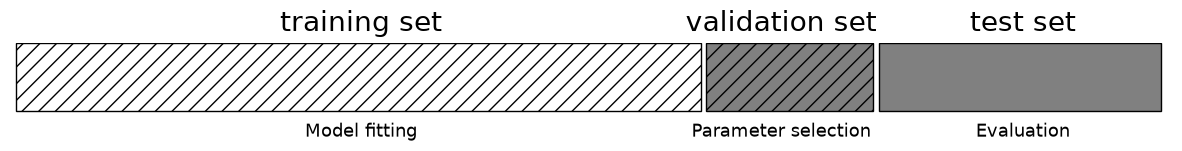

In [11]:
#訓練セット、検証セット、テストセットに分割
#訓練セットで学習し、検証セットでハイパーパラメータを調整し、最終的にテストセットで評価する

mglearn.plots.plot_threefold_split()

In [12]:
#実装してみる
from sklearn.svm import SVC

#データを訓練＋検証セットとテストセットに分割する
x_trainval,x_test,y_trainval,y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=0
)

#訓練＋検証セットを訓練セットと検証セットに分割する
x_train,x_valid,y_train,y_valid = train_test_split(
    x_trainval,
    y_trainval,
    random_state=1
)

print("Size of training set:{}".format(x_train.shape[0]))
print("Size of validation set:{}".format(x_valid.shape[0]))
print("Size of test set:{}".format(x_test.shape[0]))

best_score = 0

for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        svm = SVC(gamma=gamma,C=C)
        svm.fit(x_train,y_train)
        score = svm.score(x_valid,y_valid)
        if score > best_score:
            best_score = score
            best_parameters = {'C':C,'gamma':gamma}

#訓練セットと検証セットを用いてモデルを再構築し、テストセットで評価
svm = SVC(**best_parameters)    # ** → 辞書をキーワード引数として展開
svm.fit(x_trainval,y_trainval)
test_score = svm.score(x_test,y_test)

print("Best score on validation set:{:.2f}".format(best_score))
print("Best parameters:{}".format(best_parameters))
print("Test set score with best parameters:{:.2f}".format(test_score))

Size of training set:84
Size of validation set:28
Size of test set:38
Best score on validation set:0.96
Best parameters:{'C': 10, 'gamma': 0.001}
Test set score with best parameters:0.92


In [14]:
#交差検証を用いたグリッドサーチ
from sklearn.model_selection import cross_val_score

#訓練セットと検証セットの分割を一度だけ行うのではなく、それぞれのパラメータの組み合わせに対して交差検証を行えばいい
for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        svm = SVC(gamma=gamma,C=C)
        #交差検証を行う
        scores = cross_val_score(svm,x_trainval,y_trainval,cv=5)
        #交差検証制度の平均を計算する
        score = np.mean(scores)
        if score > best_score:
            best_score = score
            best_parameters = {'C':C,'gamma':gamma}

#訓練セットと検証セットを用いてモデルを再構築し、テストセットで評価
svm = SVC(**best_parameters)
svm.fit(x_trainval,y_trainval)
print()

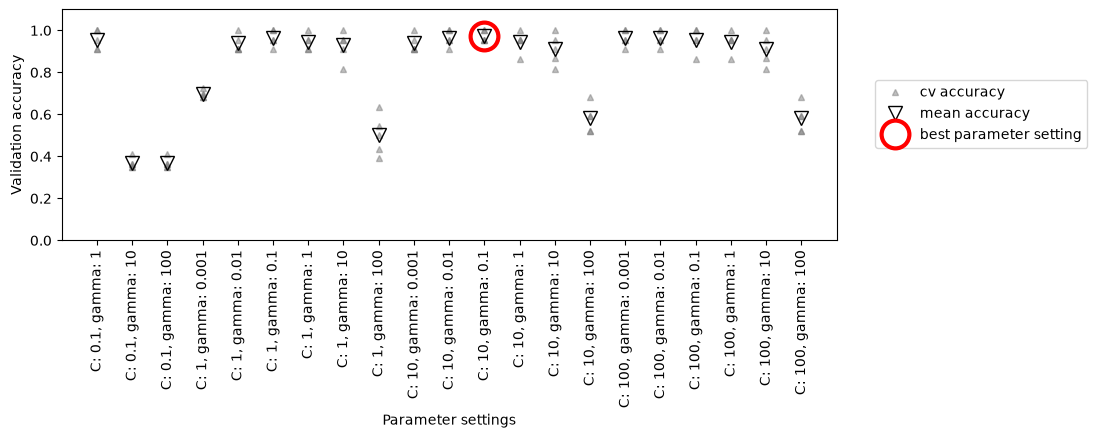

In [15]:
#上に示したコードで最良のパラメータ設定が選択される様子を示す
mglearn.plots.plot_cross_val_selection()

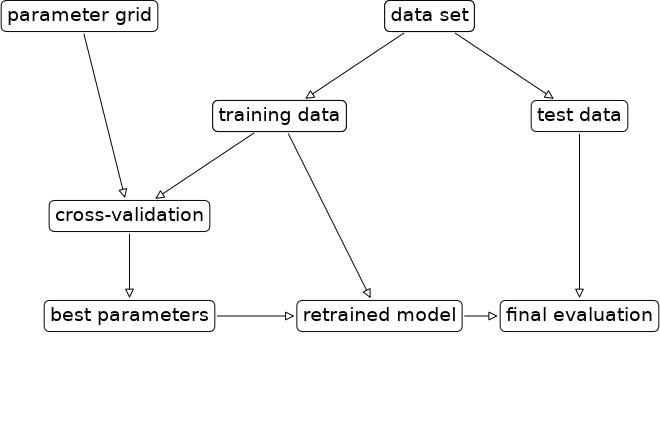

In [16]:
#データを分割し、グリッドリサーチを行い、最後のパラメータを評価する過程を示す
mglearn.plots.plot_grid_search_overview()

In [17]:
#交差検証を用いたグリッドリサーチは、非常に一般的なパラメータチューニングに使われるので、
# scikit-learnではGridSearchCVクラスを使うことで簡単に実装できる

#GridSearchCVクラスを使うには、まずディクショナリを用いて探索したいパラメータを指定する
param_grid = {
    "C" : [0.001,0.01,0.1,1,10,100],
    "gamma" : [0.001,0.01,0.1,1,10,100]
}

print("Parameter grid:\n{}".format(param_grid))

Parameter grid:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}


In [18]:
#サーチすべきパラメータのグリッド、使用したい交差検証戦略を指定してインスタンスを生成する
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

grid_search = GridSearchCV(
    SVC(),
    param_grid=param_grid,
    cv=5
)

#訓練セットと検証セットを分割する代わりに交差検証を行う
#しかし、パラメータの過剰適合を防ぐためには、さらに訓練セットとテストセットに分割しておく

x_trainval,x_test,y_trainval,y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=0
)

#fitメソッドを呼び出すと、最適なパラメータ設定をサーチするだけではなく、交差検証で最も良いスコアだったパラメータを用いて、
#自動的に訓練セット全体に対して新しいモデルを学習してくれる
grid_search.fit(x_trainval,y_trainval)

print("Test set score:{:.2f}".format(grid_search.score(x_test,y_test)))

Test set score:0.97


In [19]:
#見つけたパラメータはbest_params_属性に格納
#(訓練セットに対する)交差検証精度はbest_score_属性に格納

print("Best parameters{}".format(grid_search.best_params_))
print("Best cross-validation score:{:.2f}".format(grid_search.best_score_))

Best parameters{'C': 10, 'gamma': 0.1}
Best cross-validation score:0.97


In [20]:
# グリッドサーチの結果を表示
results = pd.DataFrame(grid_search.cv_results_)
display(results.head(5))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002943,0.001698,0.002170,0.002201,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
1,0.003584,0.001412,0.001707,0.001512,0.001,0.010,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
2,0.004839,0.004671,0.004906,0.002587,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
3,0.005767,0.000905,0.003196,0.000744,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
4,0.004594,0.004880,0.001911,0.002421,0.001,10.000,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22


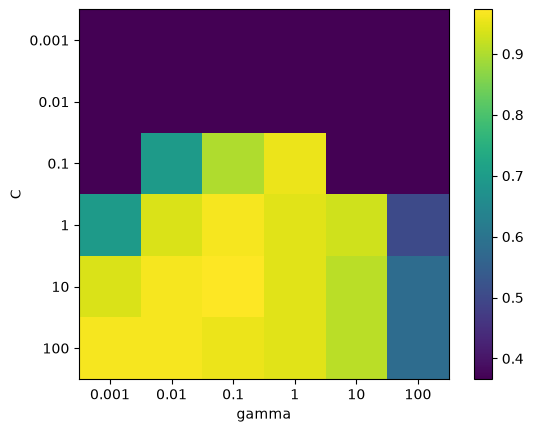

In [ ]:
#パラメータグリッドを探索しているので、ヒートマップで可視化してみる
#非常にパラメータに敏感なのがわかる
#正しいパラメータレンジにしなければならず、それぞれのパラメータの最良値がプロットの端にないようにするべき

scores = np.array(results.mean_test_score).reshape(6,6)
fig, ax = plt.subplots()

im = ax.imshow(scores, cmap="viridis")

ax.set_xticks(range(6))
ax.set_yticks(range(6))

ax.set_xticklabels(param_grid["gamma"])
ax.set_yticklabels(param_grid["C"])

ax.set_xlabel("gamma")
ax.set_ylabel("C")

plt.colorbar(im)
plt.show()

In [ ]:
#条件付きパラメータを扱うために、パラメータグリッドをディクショナリのリストにすることもできる

param_grid = [
    {
        "kernel" : ["rbf"],
        "C" : [0.001,0.01,0.1,1,10,100],
        "gamma" : [0.001,0.01,0.1,1,10,100]
    },

    {
        "kernel" : ["linear"],
        "C" : [0.001,0.01,0.1,1,10,100]
    }
]

print("List of grids:\n{}".format(param_grid))

List of grids:
[{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}, {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]


In [30]:
grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5
)
grid_search.fit(x_trainval,y_trainval)
print("Best parameters:{}".format(grid_search.best_params_))
print("Best cross-validation score:{:.2f}".format(grid_search.best_score_))

Best parameters:{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score:0.97


In [36]:
#指定した通りにkernelはlinearでCだけが変化している
results = pd.DataFrame(grid_search.cv_results_)
display(results.T)

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
mean_fit_time,0.001685,0.003289,0.00511,0.000738,0.002024,0.001082,0.002621,0.002995,0.000203,0.003665,...,0.000381,0.002793,0.003791,0.003456,0.002229,0.003014,0.002809,0.001964,0.002302,0.000548
std_fit_time,0.002445,0.003102,0.004252,0.001476,0.001845,0.001534,0.005242,0.003306,0.000407,0.004569,...,0.000762,0.004455,0.005107,0.00073,0.002876,0.00361,0.003522,0.003928,0.003675,0.001096
mean_score_time,0.001915,0.001701,0.000209,0.003489,0.001531,0.003166,0.000147,0.003581,0.003106,0.001041,...,0.001203,0.002246,0.002594,0.002668,0.002464,0.000212,0.00311,0.000696,0.001214,0.000095
std_score_time,0.003126,0.003403,0.000418,0.006484,0.002413,0.005374,0.000294,0.005195,0.001821,0.002081,...,0.001476,0.002819,0.003171,0.000744,0.003244,0.000424,0.00622,0.001391,0.002428,0.000189
param_C,0.001,0.001,0.001,0.001,0.001,0.001,0.01,0.01,0.01,0.01,...,100.0,100.0,100.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0
param_gamma,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,...,0.1,1.0,10.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN
param_kernel,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,...,rbf,rbf,rbf,rbf,linear,linear,linear,linear,linear,linear
params,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}",...,"{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 10, 'kernel': 'rbf'}","{'C': 100, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.001, 'kernel': 'linear'}","{'C': 0.01, 'kernel': 'linear'}","{'C': 0.1, 'kernel': 'linear'}","{'C': 1, 'kernel': 'linear'}","{'C': 10, 'kernel': 'linear'}","{'C': 100, 'kernel': 'linear'}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,...,1.0,0.956522,0.869565,0.521739,0.347826,0.869565,1.0,1.0,1.0,0.956522
split1_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,...,0.956522,0.956522,0.913043,0.521739,0.347826,0.869565,0.913043,0.956522,1.0,0.956522


In [37]:
# ネストした交差検証は、ハイパーパラメータの選択を含む学習手順の性能を評価する手法。
# 内側の交差検証で最適なパラメータを選択し、外側の交差検証で未知データに対する性能を評価する。
# これにより、パラメータ選択による楽観的な性能評価を抑え、特定のデータ分割への依存も軽減できる。
#あくまで、自分が考えたモデル選択手順が、どれくらい信頼できるかを調べる手法であることに注意

scores = cross_val_score(
    GridSearchCV(SVC(), param_grid, cv=5),
    iris.data,
    iris.target,
    cv=5
)

print("Cross-validation scores:{}".format(scores))
print("Mean cross-validation score:{:.2f}".format(np.mean(scores)))

Cross-validation scores:[0.96666667 1.         0.9        0.96666667 1.        ]
Mean cross-validation score:0.97


In [ ]:
#forループで見ればわかりやすい
def nested_cv(X, y, inner_cv, outer_cv, Classifier, parameter_grid):
    outer_scores = []

    for training_samples, test_samples in outer_cv.split(X, y):

        X_train, y_train = X[training_samples], y[training_samples]
        X_test, y_test = X[test_samples], y[test_samples]

        best_score = -np.inf
        best_params = None

        # 内側：最適なパラメータを探索
        for parameters in parameter_grid:
            cv_scores = []

            for inner_train, inner_test in inner_cv.split(X_train, y_train):
                clf = Classifier(**parameters)

                clf.fit(X_train[inner_train], y_train[inner_train])

                score = clf.score(X_train[inner_test], y_train[inner_test])
                cv_scores.append(score)

            mean_score = np.mean(cv_scores)

            if mean_score > best_score:
                best_score = mean_score
                best_params = parameters

        # 外側：選択したパラメータで再学習
        clf = Classifier(**best_params)
        clf.fit(X_train, y_train)

        # 外側のテストデータで性能評価
        outer_scores.append(clf.score(X_test, y_test))

    return np.array(outer_scores)

In [39]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold

scores = nested_cv(iris.data, iris.target, StratifiedKFold(5),StratifiedKFold(5), SVC, ParameterGrid(param_grid))
print("Cross-validation scores: {}".format(scores))

Cross-validation scores: [0.96666667 1.         0.96666667 0.96666667 1.        ]
